In [7]:
import pandas as pd
import numpy as np
import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import os

In [ ]:
# "indir" is a custom input path, and "outdir" is a custom output path.
indir = '../../03-stratified_RankSumTest_1vsOthers'
outdir = './'

In [ ]:
from matplotlib.font_manager import fontManager, FontProperties

path = "/arial/arial.ttf"
fontManager.addfont(path)
plt.rcParams['font.family'] = 'arial'
plt.rcParams['font.size'] = 5

prop = FontProperties(fname=path)
sns.reset_defaults()
sns.set(context=None,
    style=None,
    palette=None,
    font=prop.get_name(),
    font_scale=None,
    color_codes=None,
    rc=None,)

the_padding=0.6
red_alpha=0.7
hist_width=44
the_upper_ylim=1.075
bar_width=0.55
errorbar_setting={"ecolor":"black","elinewidth":0.6,"capsize":2.5,"capthick":0.6,"fmt":"none"}

In [6]:
def e_formatter(tick):
    the_number=str(int(tick))
    if the_number=="0":
        return "0"
    number_of_0s=0
    while the_number[-1]=="0":
        number_of_0s +=1
        the_number=the_number[:-1]
    return the_number+"e"+str(number_of_0s)
e_formatter(134050000.0)

'13405e4'

In [9]:
levels = ['01_subclasses_in_neuron_1vsOthers', '02_subclasses_in_NN_1vsOthers']

01_subclasses_in_neuron_1vsOthers
02_subclasses_in_NN_1vsOthers


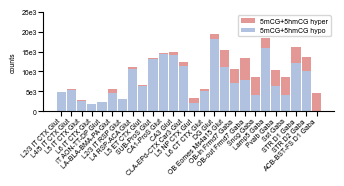

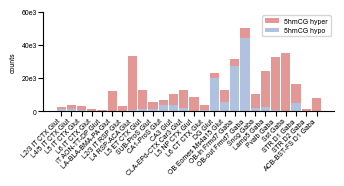

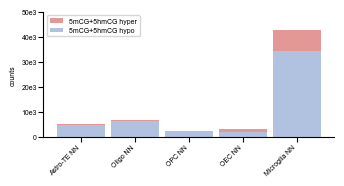

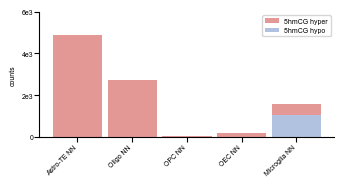

In [ ]:
for level_ in levels:
    print(level_)
    stats = pd.read_csv(f'{indir}/{level_}/{level_}_DMR_number.csv', index_col=0)
    for modification_ in ["5mCG", "5hmCG"]:
        stats2=stats.loc[stats.index!="total",
            stats.columns.str.startswith(modification_) &\
            ~(stats.columns.str.endswith("total"))]       
        
        fig, ax = plt.subplots(figsize=(90/25.4,50/25.4))
        bottom = np.zeros(stats2.shape[0])
        for type_, counts_ in stats2[stats2.columns[::-1]].to_dict().items():
            p = ax.bar(counts_.keys(), counts_.values(), width=0.9,
                       label=(("5mCG+5hmCG" if type_.split(" ")[0]=="5mCG" else "5hmCG")+\
                              " "+type_.split(" ")[1]),
                       color=("#E49895" if type_.split(" ")[1]=="hyper" else "#B0C2DF"),
                       bottom=bottom)
            bottom += np.array(list(counts_.values()), dtype=np.float64)


        #get handles and labels
        handles, labels = ax.get_legend_handles_labels()

        #specify order of items in legend
        order = [1, 0]

        #add legend to plot
        ax.legend([handles[idx] for idx in order],
          [labels[idx] for idx in order], fontsize=5)
          #loc="upper right", 
        ax.set_xticks(ticks=ax.get_xticks(),
                      labels=ax.get_xticklabels(),
                      rotation=45,
                      horizontalalignment='right',
                      verticalalignment='top',
                     fontsize=5
                     )
        ax.set_yticks(ticks=ax.get_yticks(),
                      labels=[(str(int(tick))[:-3]+"e3" if tick!=0 else "0") for tick in ax.get_yticks()],
                      fontsize=5)
        ax.tick_params(pad=1)
        ax.set_ylabel("counts", fontsize=5)

        ax.spines['right'].set_visible(False)  
        ax.spines['top'].set_visible(False)  
        plt.tight_layout()
        #plt.show()
        plt.savefig(f'{outdir}/{level_}-{modification_}-DMR_number_plot.pdf')
        plt.savefig(f'{outdir}/{level_}-{modification_}-DMR_number_plot.png', dpi=600)